In [25]:
import jit
import pandas as pd
import json
import mdps
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import cmocean

cmap = plt.colormaps["Blues"]
plt.style.use("../plotStyle.mplstyle")
my_cmap = cmocean.tools.crop_by_percent(cmocean.cm.algae, per=20, which="max")

In [2]:
vgc_predictions = pd.read_csv("vgc_predictions.csv")
vgc_predictions["probeobs"] = vgc_predictions.obstacle.str.replace("obs-", "").astype(int)
vgc_predictions["grid"] = vgc_predictions.grid.str.replace("grid-", "").astype(int)
vgc_predictions.drop(columns=["obstacle"], inplace=True)
vgc_predictions.head()


with open("data/memorytrials.json") as f:
    mem = json.load(f)
mem = pd.DataFrame(mem)
mem["correct_binary"] = mem.correct.astype(int)
mem.head()


with open("data/attentiontrials-exp1.json") as f:
    attn = json.load(f)
attn = pd.DataFrame(attn)
attn.head()

with open("data/attentiontrials-exp2.json") as f:
    attn2 = json.load(f)
attn2 = pd.DataFrame(attn2)

with open("data/attentiontrials-critical.json") as f:
    attn_critical = json.load(f)
attn_critical = pd.DataFrame(attn_critical)

with open("data/hovering-data-trials.json") as f:
    hover1 = json.load(f)
hover1 = pd.DataFrame(hover1)
hover1["grid"] = hover1.grid.astype(str).str[:-2]
hover1["grid"] = hover1.grid.str.replace("grid-", "").astype(int)
hover1["probeobs"] = hover1.obstacle.astype(int)

with open("data/hovering-data-trials-2.json") as f:
    hover2 = json.load(f)
hover2 = pd.DataFrame(hover2)
hover2["grid"] = hover2.grid.str.replace("grid-", "").astype(int)
hover2["probeobs"] = hover2.obstacle.astype(int)


with open("data/mazes_0-11.json") as f:
    init_maze = json.load(f)

    init_maze = {k[:-2]: v for k, v in init_maze.items()}

with open("data/mazes_12-15.json") as f:
    memory_maze = json.load(f)

maze = {**init_maze, **memory_maze}
dvs = {
    "initial_awareness": (attn, "response"),
    "upfront_awareness": (attn2, "response"),
    "critical_memory": (mem, "correct"),
    "critical_confidence": (mem, "response_conf"),
    "critical_awareness": (attn_critical, "response"),
    "initial_hover": (hover1, "hovered"),
    "initial_loghover_duration": (hover1, "log_hoverduration"),
    "critical_hover": (hover2, "hovered"),
    "critical_loghover_duration": (hover2, "log_hoverduration"),
}

def get_jit_predictions(measures):
    out = []
    # for dv, (data, colname) in dvs.items():
    for dv in measures:
        data, colname = dvs[dv]
        fit_results = pd.read_csv(f"output/decay_astar_straight/fit-{dv}.csv")

        best_pars = fit_results.iloc[fit_results["r2"].idxmax()]

        try:
            noise_floor = best_pars["noise_floor"]
        except KeyError:
            noise_floor = 0.00

        pars = jit.AStarPars(best_pars["alpha_d"], best_pars["alpha_h"], best_pars["decay"], noise_floor)
        model_pred = jit.AStarRolloutStraight.predict(pars, data.grid.unique(), 300)
        model_pred["dv"] = dv
        model_pred["params"] = str(pars)
        # model_pred["prob"] = np.clip(model_pred.prob, 0.1, 1.0)
        print(model_pred.head())
        out.append(model_pred)
    model_preds = pd.concat(out, ignore_index=True)
    return model_preds

# jit_predictions = get_jit_predictions(["critical_memory", "initial_hover", "critical_hover"])
# get_jit_predictions().to_csv("jit_predictions.csv", index=False)
jit_predictions = pd.read_csv("jit_predictions.csv")

In [3]:
from importlib import reload
reload(mdps)

<module 'mdps' from '/Users/tony/repos/physics_events/navigation/mdps.py'>

In [63]:
def heatmap(dv, grid, jit_predictions, vgc, df, norm=True, ax=None, verbose=False, cmap=plt.colormaps["Blues"], width=0, ground_truth=True):
    human_df, colname = dvs[dv]

    suffix = f" \ngrid {grid}" if verbose else ""
    if ax is None:
        fig, ax = plt.subplots(1, 4, figsize=(12, 3))
    g = mdps.GridWorld.from_string(maze[f"grid-{grid}"])

    tmp = vgc.loc[(vgc.grid == grid) & (vgc.dv == dv)]
    # colors = [cmap(tmp.loc[tmp.probeobs == int(i), "static_vgc"].iloc[0]) if i != "#" else (0, 0, 0, 1) for i in g.obstacle_names]
    idx = 0
    if ground_truth:
        g.viz(start=(0, 0), ax=ax[0], width=width)
        ax[idx].set_title(f"Ground Truth{suffix}", fontsize=20)
        ax[idx].set_axis_off()
        ax[idx].set_aspect('equal')
        idx += 1

    agg = human_df.groupby(['grid', 'probeobs'])[colname].mean().reset_index()
    tmp = agg.loc[(agg.grid == grid)].reset_index()
    tmp["response"] = tmp[colname]
    if norm:
        rmin = tmp.response.min()
        rmax = tmp.response.max()
        tmp["response"] = (tmp.response - rmin) / (rmax - rmin)  # normalize to between 0 and 1

    colors = [cmap(tmp.loc[tmp.probeobs == int(i), "response"].iloc[0]) if i != "#" else (0, 0, 0, 1) for i in g.obstacle_names]
    g.viz(start=(0, 0), colors=colors, ax=ax[idx], width=width)
    ax[idx].set_title(f"Humans{suffix}", fontsize=15)
    # ax[idx].set_axis_off()
    idx += 1

    tmp = jit_predictions.loc[jit_predictions.dv == dv].query(f"grid == {grid}")
    colors = [cmap(tmp.loc[tmp.probeobs == int(i), "prob"].iloc[0]) if i != "#" else (0, 0, 0, 1) for i in g.obstacle_names]
    # print(colors)
    g.viz(start=(0, 0), colors=colors, ax=ax[idx], width=width)
    # norm = mcolors.Normalize(vmin=0, vmax=1)
    ax[idx].set_title(f"JIT{suffix}", fontsize=15)
    # ax[idx].set_axis_off()
    idx += 1

    tmp = vgc.loc[(vgc.grid == grid) & (vgc.dv == dv)]
    colors = [cmap(tmp.loc[tmp.probeobs == int(i), "dynamic_vgc"].iloc[0]) if i != "#" else (0, 0, 0, 1) for i in g.obstacle_names]
    g.viz(start=(0, 0), colors=colors, ax=ax[idx], width=width)
    # ax[3].set_title(f"Dynamic VGC{suffix}", fontsize=15)
    ax[idx].set_title(f"VGC{suffix}", fontsize=15)
    # ax[idx].set_axis_off()
    # ax[idx].set_xticks([])
    # ax[idx].set_yticks([])
    # ax[idx].spines[:].set_visible(False)
    # ax[idx].set_aspect('equal')

    for a in ax:
        a.set_xticks([])
        a.set_yticks([])
        a.spines[:].set_visible(False)
        a.set_aspect('equal', 'box')

    # normalize to between 0 and 1
    # tmp["response"] = ( tmp.hovered - rmin) / (rmax - rmin)

In [ ]:
def heatmap_horizontal(dv, grid, jit_predictions, vgc, df=None, norm=True, ax=None, verbose=False, cmap=plt.colormaps["Blues"], width=0, ground_truth=True):
    human_df, colname = dvs[dv]

    suffix = f" \ngrid {grid}" if verbose else ""
    if ax is None:
        fig, ax = plt.subplots(4 if ground_truth else 3, 1, figsize=(12, 3))
    g = mdps.GridWorld.from_string(maze[f"grid-{grid}"])

    tmp = vgc.loc[(vgc.grid == grid) & (vgc.dv == dv)]
    # colors = [cmap(tmp.loc[tmp.probeobs == int(i), "static_vgc"].iloc[0]) if i != "#" else (0, 0, 0, 1) for i in g.obstacle_names]
    idx = 0
    if ground_truth:
        g.viz(start=(0, 0), ax=ax[0], width=width)
        ax[idx].set_title(f"Ground Truth{suffix}", fontsize=20)
        ax[idx].set_axis_off()
        ax[idx].set_aspect('equal')
        idx += 1

    agg = human_df.groupby(['grid', 'probeobs'])[colname].mean().reset_index()
    tmp = agg.loc[(agg.grid == grid)].reset_index()
    tmp["response"] = tmp[colname]
    if norm:
        rmin = tmp.response.min()
        rmax = tmp.response.max()
        tmp["response"] = (tmp.response - rmin) / (rmax - rmin)  # normalize to between 0 and 1

    colors = [cmap(tmp.loc[tmp.probeobs == int(i), "response"].iloc[0]) if i != "#" else (0, 0, 0, 1) for i in g.obstacle_names]
    g.viz(start=(0, 0), colors=colors, ax=ax[idx], width=width)
    ax[idx].set_title(f"Humans{suffix}", fontsize=20, rotation=90, y=0.25, x=-0.10)
    ax[idx].set_axis_off()
    ax[idx].set_aspect("equal")
        # fig.subplots_adjust(top=0.9)
        # fig.suptitle(f"{dv}")
    idx += 1

    tmp = jit_predictions.loc[jit_predictions.dv == dv].query(f"grid == {grid}")
    colors = [cmap(tmp.loc[tmp.probeobs == int(i), "prob"].iloc[0]) if i != "#" else (0, 0, 0, 1) for i in g.obstacle_names]
    # print(colors)
    g.viz(start=(0, 0), colors=colors, ax=ax[idx], width=width)
    ax[idx].set_title(f"JIT{suffix}", fontsize=20, rotation=90, y=0.35, x=-0.10)
    ax[idx].set_axis_off()
    ax[idx].set_aspect('equal')
    idx += 1

    tmp = vgc.loc[(vgc.grid == grid) & (vgc.dv == dv)]
    colors = [cmap(tmp.loc[tmp.probeobs == int(i), "dynamic_vgc"].iloc[0]) if i != "#" else (0, 0, 0, 1) for i in g.obstacle_names]
    g.viz(start=(0, 0), colors=colors, ax=ax[idx], width=width)
    # ax[3].set_title(f"Dynamic VGC{suffix}", fontsize=20)
    ax[idx].set_title(f"VGC{suffix}", fontsize=20, rotation=90, y=0.35, x=-0.10)
    ax[idx].set_axis_off()
    ax[idx].set_aspect('equal')

    for a in ax:
        a.set_xticks([])
        a.set_yticks([])
        a.spines[:].set_visible(False)

    # normalize to between 0 and 1
    # tmp["response"] = ( tmp.hovered - rmin) / (rmax - rmin)

/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_1378/1292631349.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])


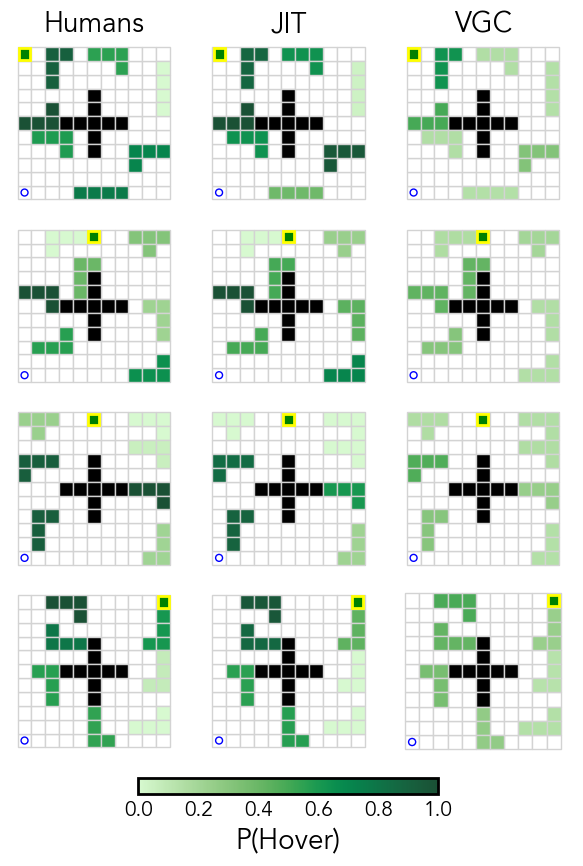

In [7]:
my_cmap = cmocean.tools.crop_by_percent(cmocean.cm.algae, per=20, which="max")
dv = "initial_hover"

grids = [2, 6, 7, 11]
rows, cols = len(grids), 3
fig = plt.figure(figsize=(cols * 2, rows * 2))
gs = fig.add_gridspec(rows, cols)
axes = []
for i in range(rows):
    axes.append([fig.add_subplot(gs[i, j]) for j in range(cols)])
# fig, axes = plt.subplots(len(grids), 4, figsize=(11, len(grids) * 3))
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=my_cmap, ground_truth=False)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")

# colorbar_ax = fig.add_subplot(gs[-1, 0:rows])
colorbar_ax = fig.add_axes([0.25, 0.00, 0.5, 0.02])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.0, vmax=1.0), cmap=my_cmap), cax=colorbar_ax, orientation='horizontal', label='P(Hover)', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
colorbar_ax.set_xmargin(0.1)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("../figures/navigation_heatmaps_algae.png", bbox_inches="tight", dpi=300)

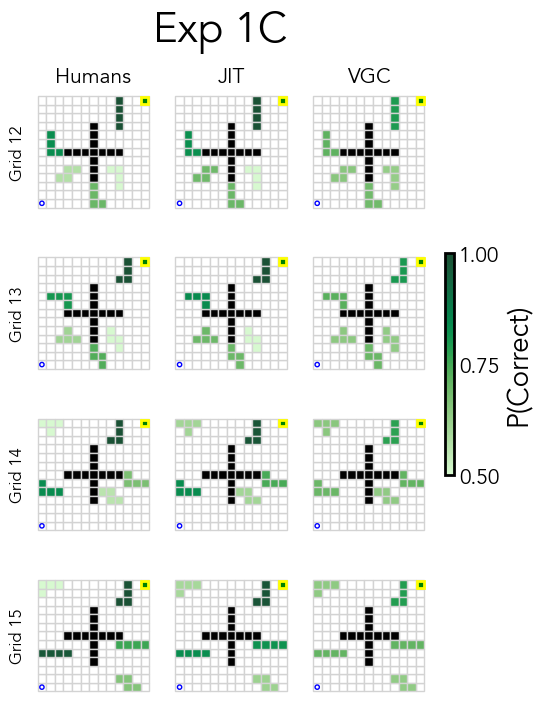

In [75]:
dv = "critical_memory"
grids = range(12, 16) if "critical" in dv else range(12)
rows, cols = len(grids), 3
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, 2.1 * rows - 1))
# axes = np.array(axes).T
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=my_cmap, ground_truth=False)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")
    axes[i, 0].set_ylabel(f"Grid {grid}", fontsize=12)

fig.tight_layout()
fig.subplots_adjust(top=0.90)
fig.suptitle("Exp 1C", fontsize=30)
# colorbar_ax = fig.add_axes([0.25, 0.00, 0.5, 0.02])
colorbar_ax = fig.add_axes([1.0, 0.35, 0.02, 0.3])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.5, vmax=1.0), cmap=my_cmap), cax=colorbar_ax, orientation='vertical', label='P(Correct)', ticks=[0.5, 0.75, 1.0])
colorbar_ax.set_xmargin(0.1)
# plt.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig("../figures/navigation_recall_heatmap.pdf", bbox_inches="tight")

/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_64419/3128367367.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


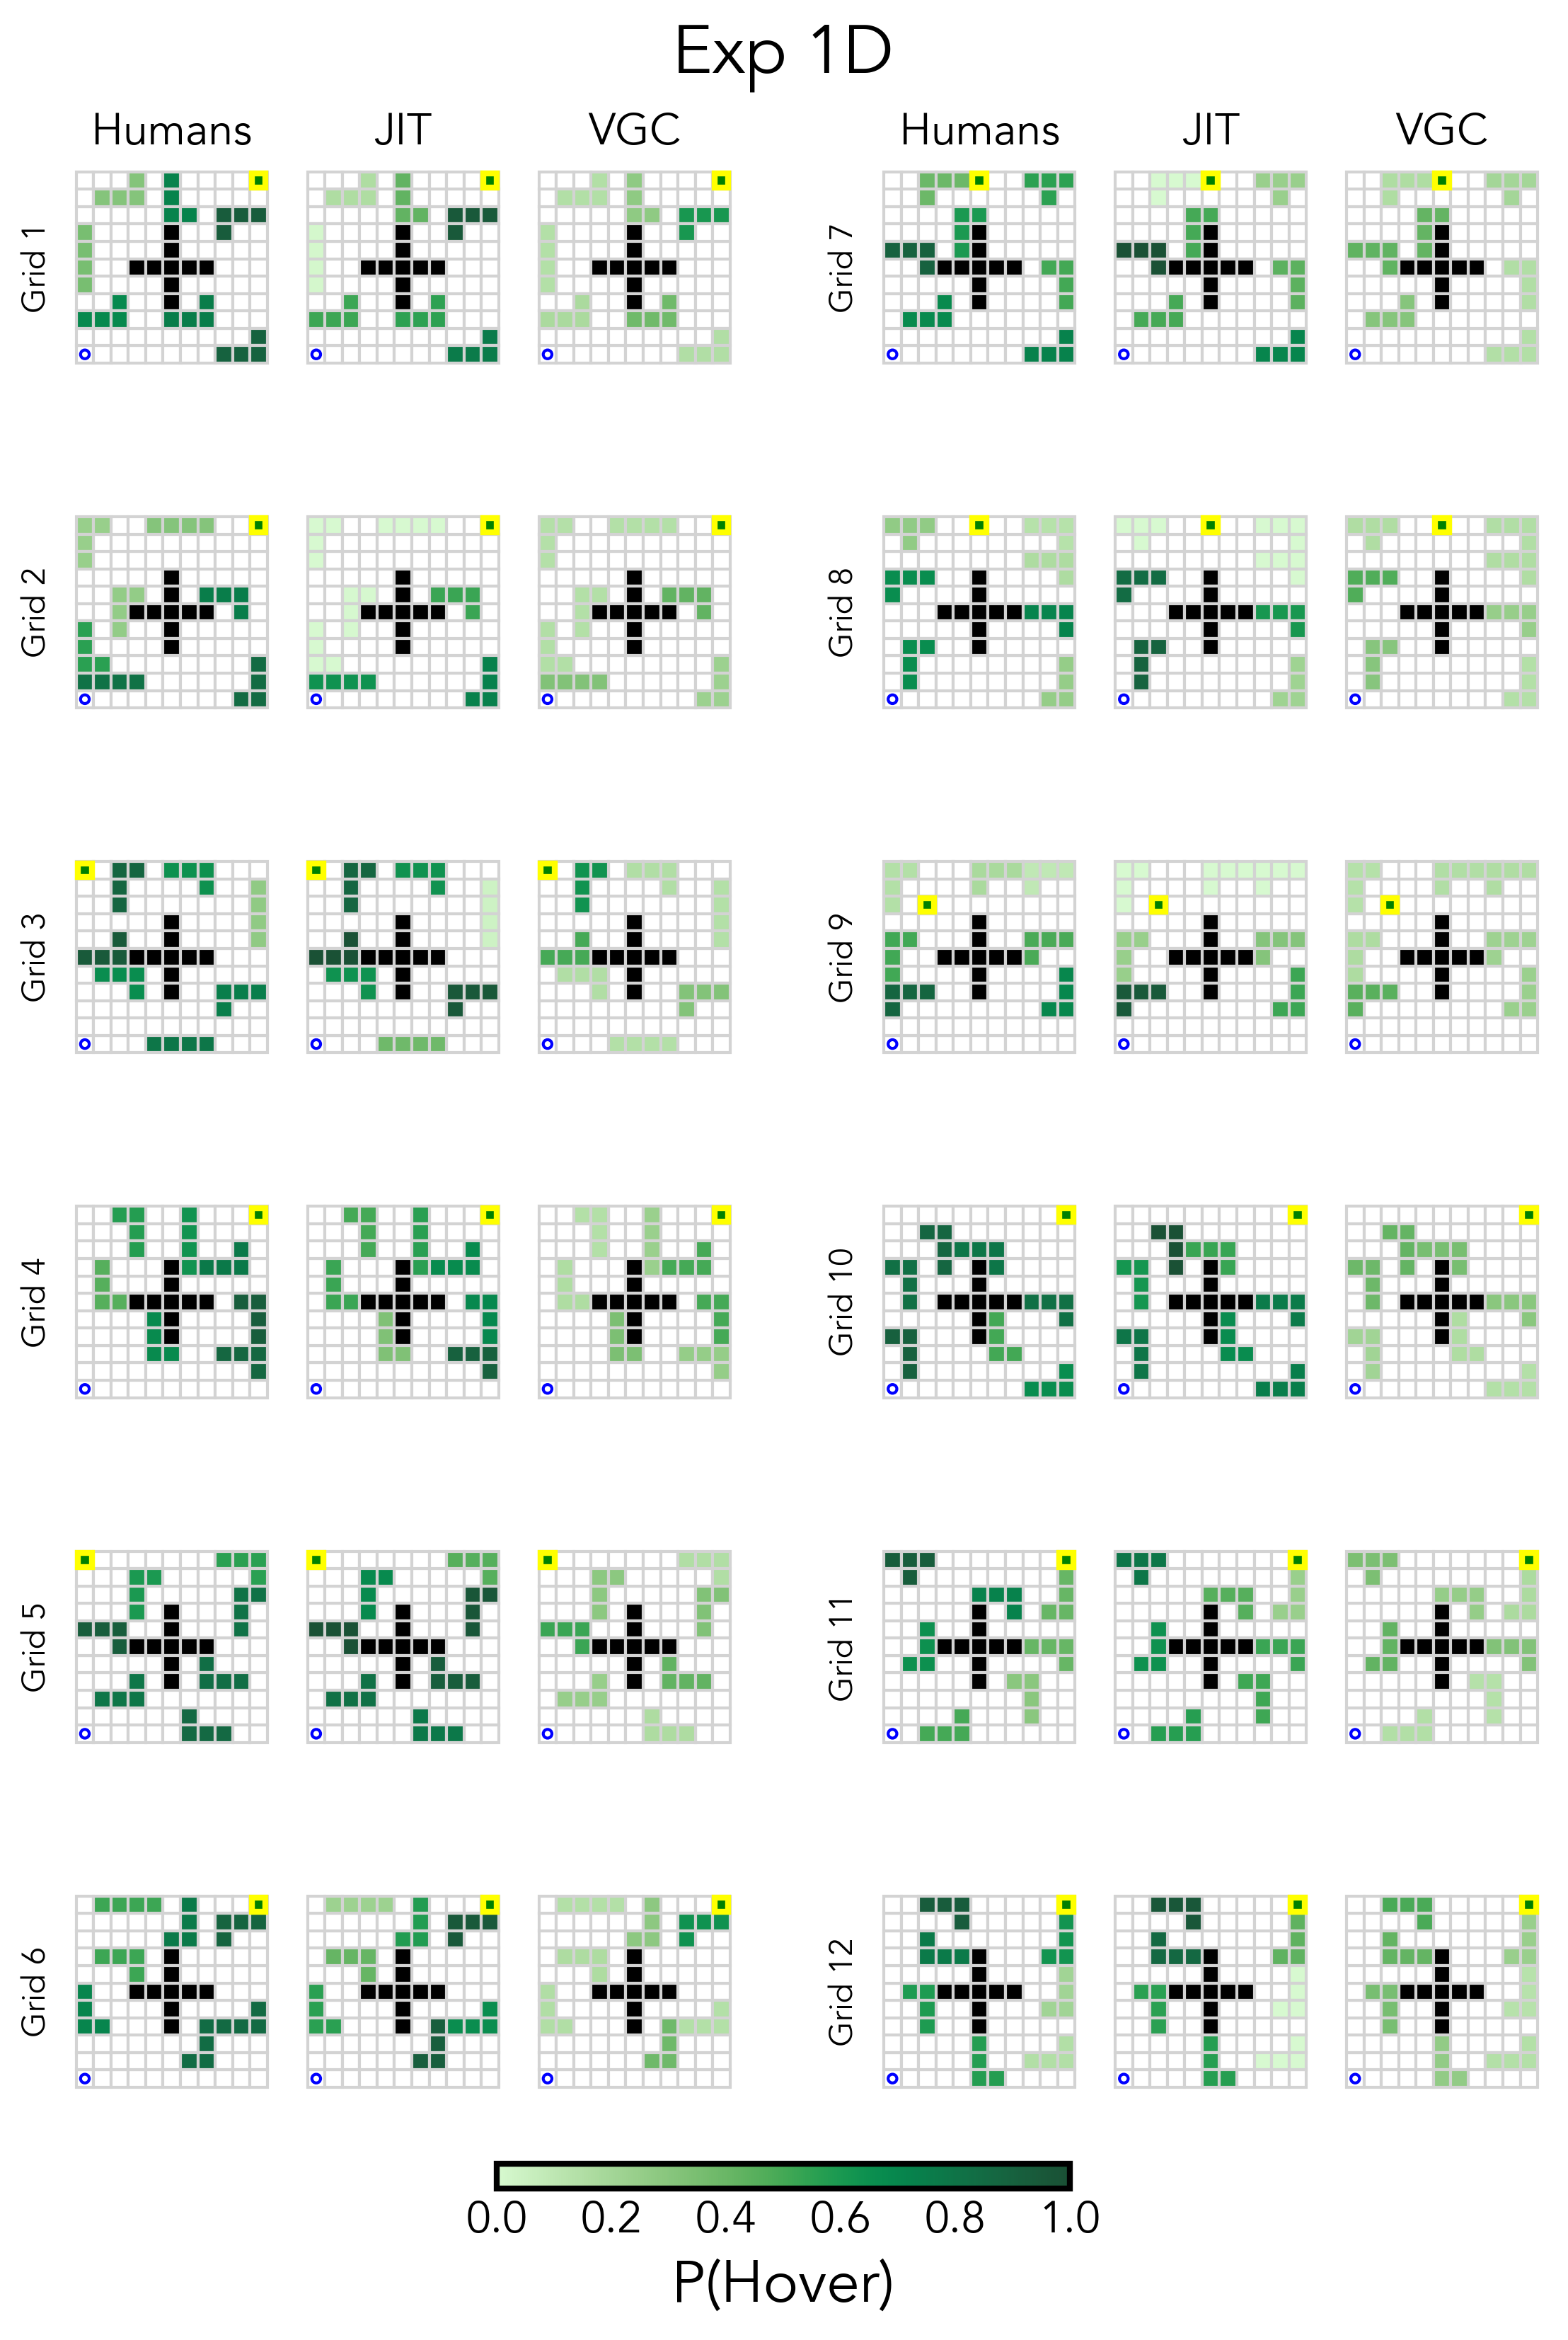

In [82]:
dv = "initial_hover"
# grids = range(12, 16) if "critical" in dv else range(12)
# grids = range(6)
grids = list(range(12))
rows, cols = len(grids), 3
fig = plt.figure(figsize=(1.5 * 6, 2.1 * (len(grids) // 2) - 1), dpi=300)
outer = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.2)

nrow = len(grids)//2
left = gridspec.GridSpecFromSubplotSpec(nrow, cols, subplot_spec=outer[0], wspace=0.1, hspace=0.00)
right = gridspec.GridSpecFromSubplotSpec(nrow, cols, subplot_spec=outer[1], wspace=0.1, hspace=0.00)

for j, gs in enumerate([left, right]):
    for i, grid in enumerate(grids[j*nrow:(j+1)*nrow]):
        axes = []
        for k in range(3):
            axes.append(fig.add_subplot(gs[i, k]))
        heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=False, ax=axes, cmap=my_cmap, ground_truth=False)
        axes[0].set_ylabel(f"Grid {j*nrow + i+1}", fontsize=11)
        if i % nrow != 0:
            for ax in axes:
                ax.set_title("")
fig.suptitle("Exp 1D")
fig.subplots_adjust(top=0.95)
colorbar_ax = fig.add_axes([0.35, 0.10, 0.3, 0.01])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.0, vmax=1.0), cmap=my_cmap), cax=colorbar_ax, orientation='horizontal', label='P(Hover)', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
fig.tight_layout()
fig.savefig("../figures/navigation_inithover_heatmap1.pdf", bbox_inches="tight")

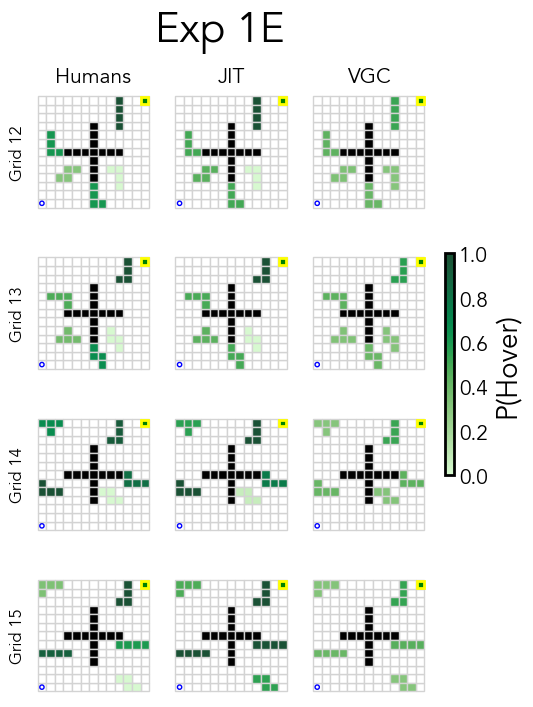

In [76]:
dv = "critical_hover"
grids = range(12, 16) if "critical" in dv else range(12)
rows, cols = len(grids), 3
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, 2.1 * rows - 1))
# axes = np.array(axes).T
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=my_cmap, ground_truth=False)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")
    axes[i, 0].set_ylabel(f"Grid {grid}", fontsize=12)

fig.tight_layout()
fig.subplots_adjust(top=0.90)
colorbar_ax = fig.add_axes([1.0, 0.35, 0.02, 0.3])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.0, vmax=1.0), cmap=my_cmap), cax=colorbar_ax, orientation='vertical', label='P(Hover)', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
fig.suptitle("Exp 1E", fontsize=30)
fig.savefig("../figures/navigation_crithover_heatmap.pdf", bbox_inches="tight")

/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_86293/513381265.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])


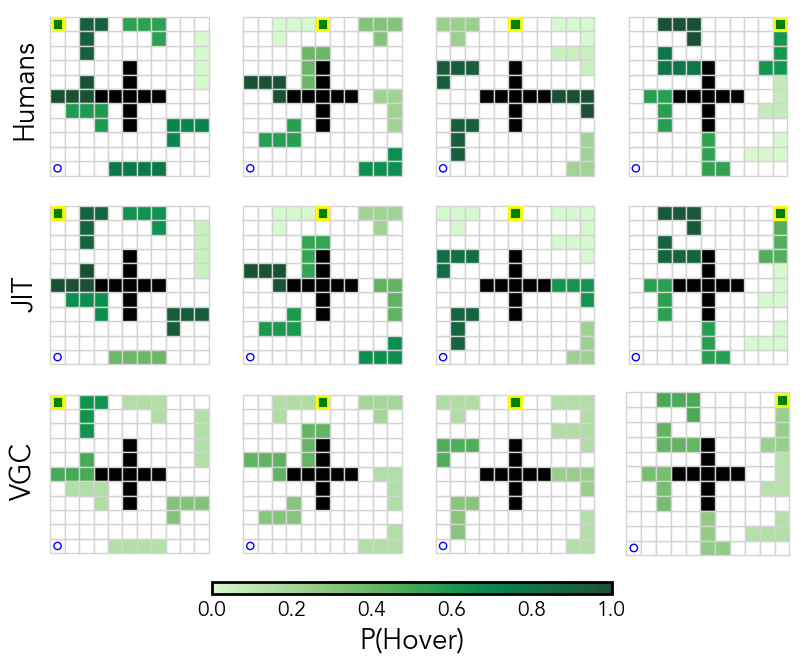

In [127]:
my_cmap = cmocean.tools.crop_by_percent(cmocean.cm.algae, per=20, which="max")
dv = "initial_hover"

grids = [2, 6, 7, 11]
cols, rows = len(grids), 3
fig = plt.figure(figsize=(cols * 2, rows * 2))
gs = fig.add_gridspec(rows, cols)
axes = []
for i in range(rows):
    axes.append([fig.add_subplot(gs[i, j]) for j in range(cols)])
axes = np.array(axes).T
# fig, axes = plt.subplots(len(grids), 4, figsize=(11, len(grids) * 3))
for i, grid in enumerate(grids):
    heatmap_horizontal(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=my_cmap, ground_truth=False)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")

# colorbar_ax = fig.add_subplot(gs[-1, 0:rows])
colorbar_ax = fig.add_axes([0.25, 0.00, 0.5, 0.02])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.0, vmax=1.0), cmap=my_cmap), cax=colorbar_ax, orientation='horizontal', label='P(Hover)', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
colorbar_ax.set_xmargin(0.1)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("../figures/navigation_heatmaps_algae.png", bbox_inches="tight", dpi=300)

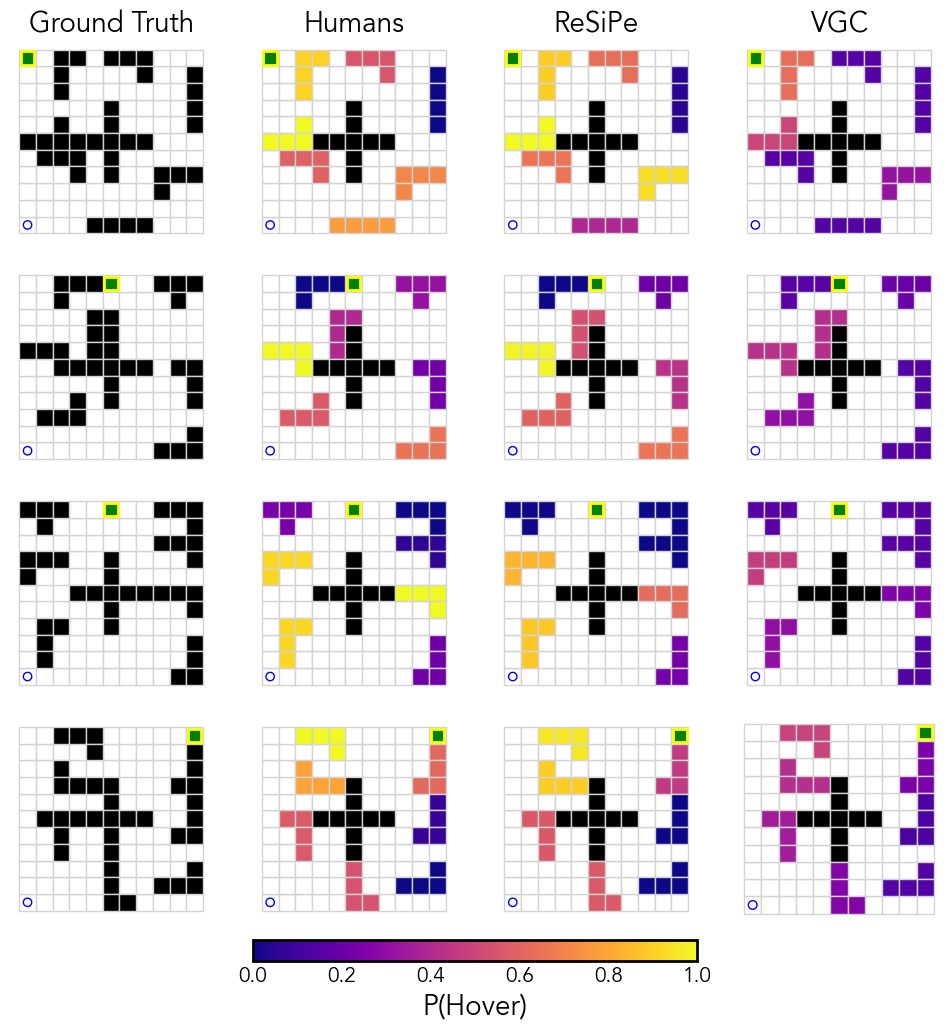

In [34]:
dv = "initial_hover"
# make axes 4 x 4 with an 1 x 4 bottom row for the colorbar
grids = [2, 6, 7, 11]
fig = plt.figure(figsize=(12, len(grids) * 3))
height_ratios = [1] * len(grids) + [0.1]
gs = fig.add_gridspec(len(grids) + 1, 4, height_ratios=height_ratios, hspace=0.1)
axes = []
for i in range(len(grids)):
    axes.append([fig.add_subplot(gs[i, j]) for j in range(4)])
# fig, axes = plt.subplots(len(grids), 4, figsize=(11, len(grids) * 3))
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=plt.colormaps["plasma"])
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")

colorbar_ax = fig.add_subplot(gs[-1, 1:-1])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.0, vmax=1), cmap=plt.colormaps["plasma"]), cax=colorbar_ax, orientation='horizontal', label='P(Hover)', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
colorbar_ax.set_xmargin(0.1)
fig.savefig("../figures/navigation_heatmaps.png", bbox_inches="tight", dpi=300)

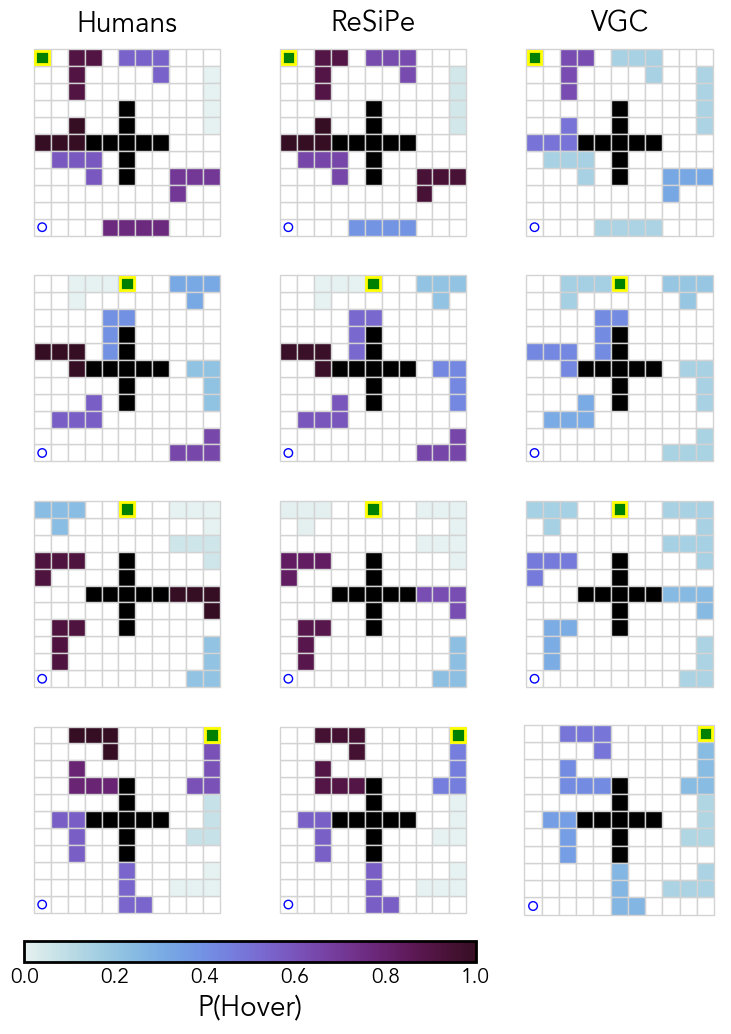

In [45]:
import cmocean

my_cmap = cmocean.cm.dense
dv = "initial_hover"

grids = [2, 6, 7, 11]
rows, cols = len(grids), 3
fig = plt.figure(figsize=(cols * 3, rows * 3))
height_ratios = [1] * rows + [0.1]
gs = fig.add_gridspec(rows + 1, cols, height_ratios=height_ratios, hspace=0.1)
axes = []
for i in range(rows):
    axes.append([fig.add_subplot(gs[i, j]) for j in range(cols)])
# fig, axes = plt.subplots(len(grids), 4, figsize=(11, len(grids) * 3))
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=my_cmap, ground_truth=False)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")

colorbar_ax = fig.add_subplot(gs[-1, 0:-1])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.0, vmax=1.0), cmap=my_cmap), cax=colorbar_ax, orientation='horizontal', label='P(Hover)', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
colorbar_ax.set_xmargin(0.1)
# fig.subplots_adjust(top=0.90)
# fig.suptitle("Hover", fontsize=30)

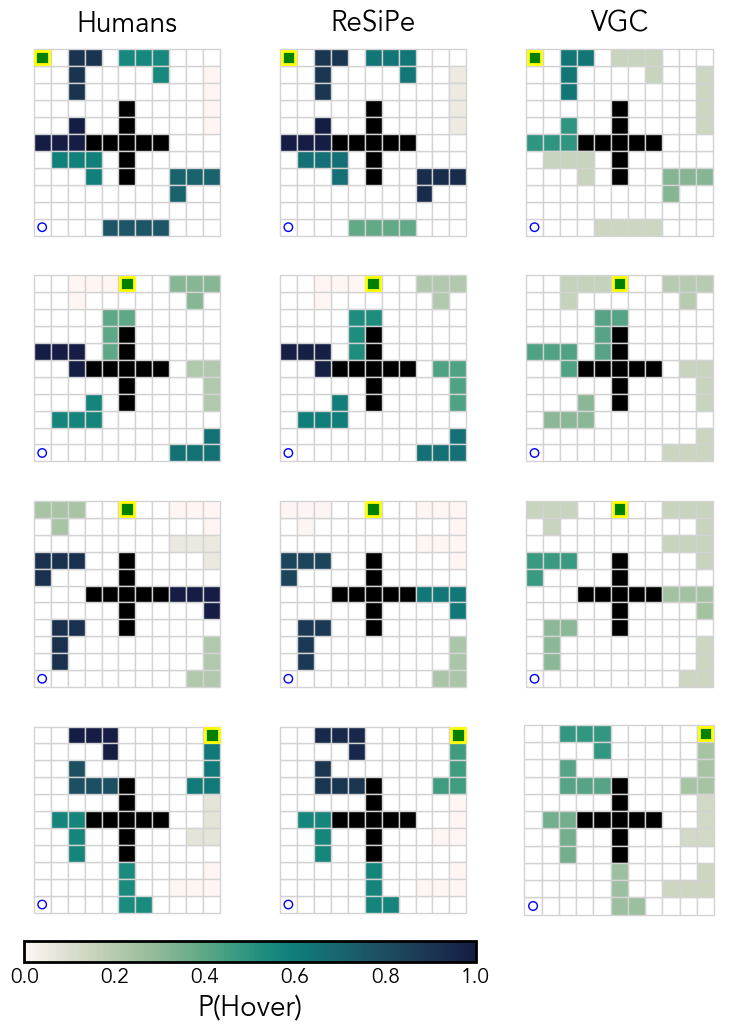

In [44]:
import cmocean

my_cmap = cmocean.cm.tempo
dv = "initial_hover"

grids = [2, 6, 7, 11]
rows, cols = len(grids), 3
fig = plt.figure(figsize=(cols * 3, rows * 3))
height_ratios = [1] * rows + [0.1]
gs = fig.add_gridspec(rows + 1, cols, height_ratios=height_ratios, hspace=0.1)
axes = []
for i in range(rows):
    axes.append([fig.add_subplot(gs[i, j]) for j in range(cols)])
# fig, axes = plt.subplots(len(grids), 4, figsize=(11, len(grids) * 3))
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=my_cmap, ground_truth=False)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")

colorbar_ax = fig.add_subplot(gs[-1, 0:-1])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.0, vmax=1.0), cmap=my_cmap), cax=colorbar_ax, orientation='horizontal', label='P(Hover)', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
colorbar_ax.set_xmargin(0.1)
# fig.subplots_adjust(top=0.90)
# fig.suptitle("Hover", fontsize=30)

/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_86293/3757786053.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])


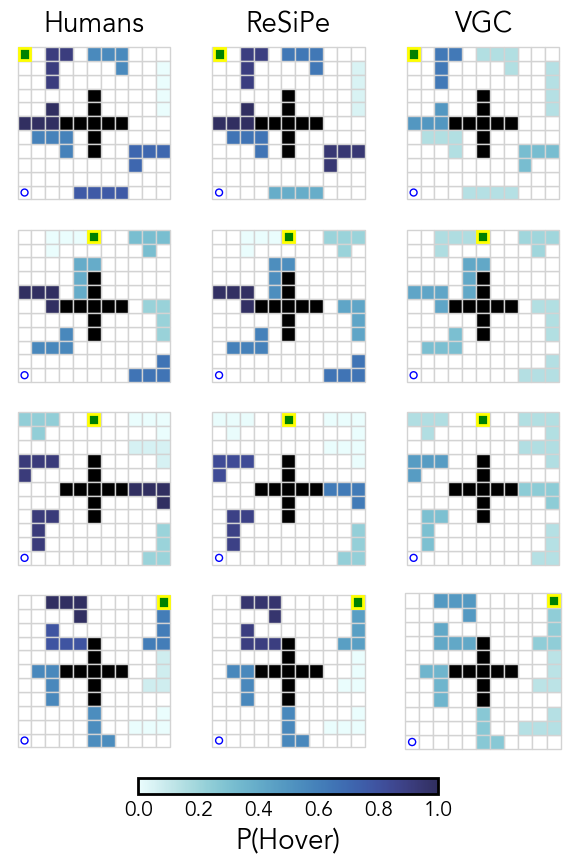

In [ ]:
my_cmap = cmocean.tools.crop_by_percent(cmocean.cm.ice_r, per=20, which="max")
dv = "initial_hover"

grids = [2, 6, 7, 11]
rows, cols = len(grids), 3
fig = plt.figure(figsize=(cols * 2, rows * 2))
# height_ratios = [1] * rows + [0.1]
# gs = fig.add_gridspec(rows, cols, height_ratios=height_ratios, hspace=0.1)
gs = fig.add_gridspec(rows, cols)
axes = []
for i in range(rows):
    axes.append([fig.add_subplot(gs[i, j]) for j in range(cols)])
axes = np.array(axes)
# fig, axes = plt.subplots(len(grids), 4, figsize=(11, len(grids) * 3))
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=my_cmap, ground_truth=False)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")

# colorbar_ax = fig.add_subplot(gs[-1, 0:rows])
colorbar_ax = fig.add_axes([0.25, 0.00, 0.5, 0.02])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.0, vmax=1.0), cmap=my_cmap), cax=colorbar_ax, orientation='horizontal', label='P(Hover)', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
colorbar_ax.set_xmargin(0.1)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("../figures/navigation_heatmaps_ice.png", bbox_inches="tight", dpi=300)

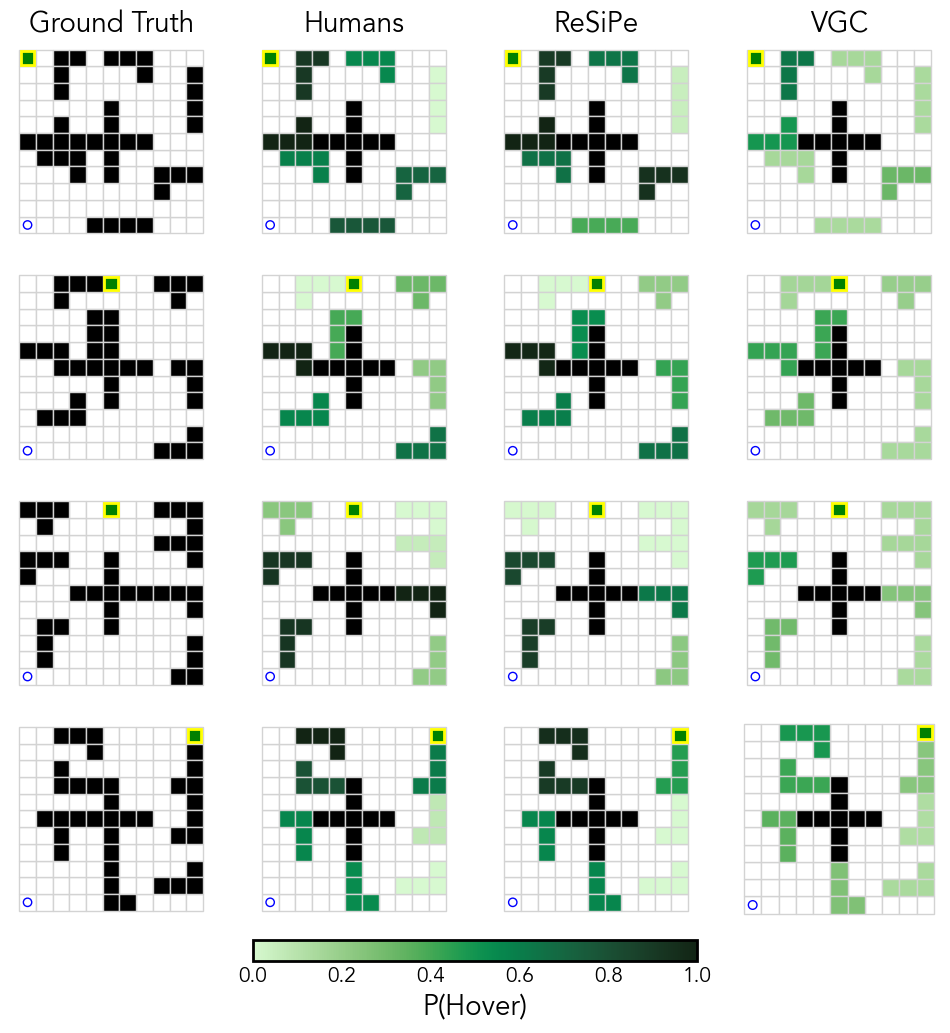

In [19]:
import cmocean

my_cmap = cmocean.cm.algae
dv = "initial_hover"

grids = [2, 6, 7, 11]
fig = plt.figure(figsize=(12, len(grids) * 3))
height_ratios = [1] * len(grids) + [0.1]
gs = fig.add_gridspec(len(grids) + 1, 4, height_ratios=height_ratios, hspace=0.1)
axes = []
for i in range(len(grids)):
    axes.append([fig.add_subplot(gs[i, j]) for j in range(4)])
# fig, axes = plt.subplots(len(grids), 4, figsize=(11, len(grids) * 3))
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=my_cmap)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")

colorbar_ax = fig.add_subplot(gs[-1, 1:-1])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.0, vmax=1), cmap=my_cmap), cax=colorbar_ax, orientation='horizontal', label='P(Hover)', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
colorbar_ax.set_xmargin(0.1)
# fig.subplots_adjust(top=0.90)
# fig.suptitle("Hover", fontsize=30)

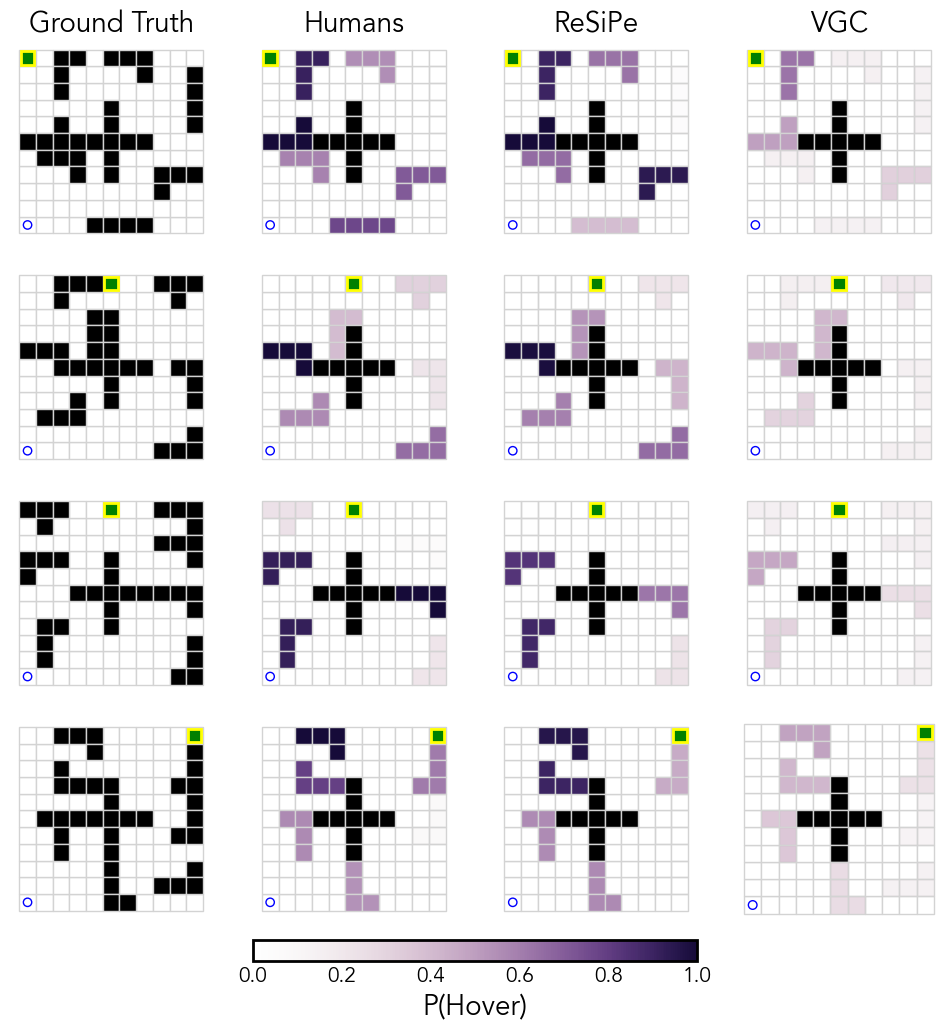

In [25]:
dv = "initial_hover"
# make axes 4 x 4 with an 1 x 4 bottom row for the colorbar
cmap_points = []
for i in np.linspace(0, 1, 20):
    #c = np.array([0.9, 0.9, 0.9, 0]) * (1 - i) + np.array([0, 0, 1, 1]) * i
    c_original = plt.colormaps["inferno_r"](.5 + i * 0.4)
    c = np.array([0.9, 0.9, 0.9, i]) * (1 - i) + np.array(c_original) * i
    # c = np.array([*c_original[:3], i])
    # c = np.array([0.9, 0.9, 0.9, 1]) * (1 - i) + np.array(c_original) * i

    cmap_points.append(c)

my_cmap = mcolors.LinearSegmentedColormap.from_list("my_cmap", cmap_points)
grids = [2, 6, 7, 11]
fig = plt.figure(figsize=(12, len(grids) * 3))
height_ratios = [1] * len(grids) + [0.1]
gs = fig.add_gridspec(len(grids) + 1, 4, height_ratios=height_ratios, hspace=0.1)
axes = []
for i in range(len(grids)):
    axes.append([fig.add_subplot(gs[i, j]) for j in range(4)])
# fig, axes = plt.subplots(len(grids), 4, figsize=(11, len(grids) * 3))
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=my_cmap)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")

colorbar_ax = fig.add_subplot(gs[-1, 1:-1])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.0, vmax=1), cmap=my_cmap), cax=colorbar_ax, orientation='horizontal', label='P(Hover)', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
colorbar_ax.set_xmargin(0.1)
# fig.subplots_adjust(top=0.90)
# fig.suptitle("Hover", fontsize=30)

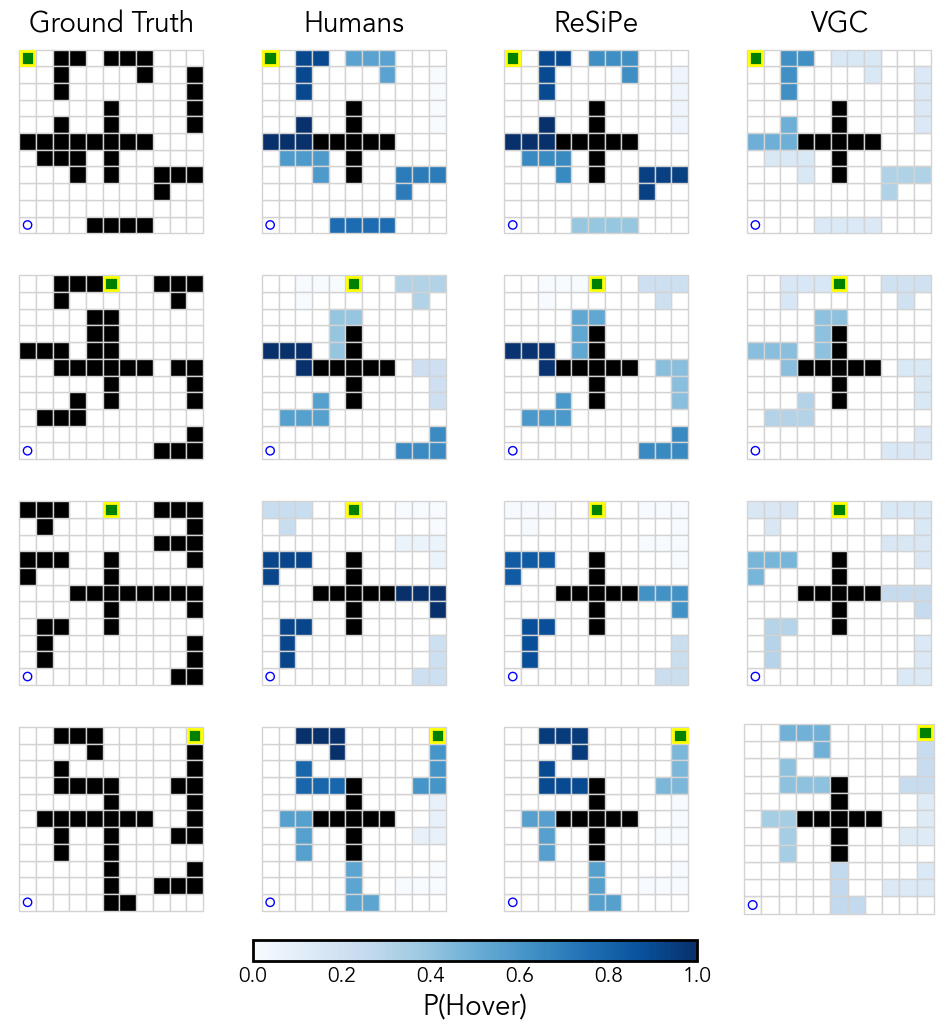

In [26]:
dv = "initial_hover"
my_cmap = plt.colormaps["Blues"]
grids = [2, 6, 7, 11]
fig = plt.figure(figsize=(12, len(grids) * 3))
height_ratios = [1] * len(grids) + [0.1]
gs = fig.add_gridspec(len(grids) + 1, 4, height_ratios=height_ratios, hspace=0.1)
axes = []
for i in range(len(grids)):
    axes.append([fig.add_subplot(gs[i, j]) for j in range(4)])
# fig, axes = plt.subplots(len(grids), 4, figsize=(11, len(grids) * 3))
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=my_cmap)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")

colorbar_ax = fig.add_subplot(gs[-1, 1:-1])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.0, vmax=1), cmap=my_cmap), cax=colorbar_ax, orientation='horizontal', label='P(Hover)', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
colorbar_ax.set_xmargin(0.1)
# fig.subplots_adjust(top=0.90)
# fig.suptitle("Hover", fontsize=30)

In [ ]:
dv = "initial_hover"
# make axes 4 x 4 with an 1 x 4 bottom row for the colorbar
grids = [2, 6, 7, 11]
fig = plt.figure(figsize=(12, len(grids) * 3))
height_ratios = [1] * len(grids) + [0.1]
gs = fig.add_gridspec(len(grids) + 1, 4, height_ratios=height_ratios, hspace=0.1)
axes = []
for i in range(len(grids)):
    axes.append([fig.add_subplot(gs[i, j]) for j in range(4)])
# fig, axes = plt.subplots(len(grids), 4, figsize=(11, len(grids) * 3))
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=plt.colormaps["Blues"])
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")

colorbar_ax = fig.add_subplot(gs[-1, 1:-1])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.0, vmax=1), cmap=plt.colormaps["Blues"]), cax=colorbar_ax, orientation='horizontal', label='P(Hover)', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
colorbar_ax.set_xmargin(0.1)
# fig.subplots_adjust(top=0.90)
# fig.suptitle("Hover", fontsize=30)

In [ ]:
dv = "initial_hover"
# make axes 4 x 4 with an 1 x 4 bottom row for the colorbar
grids = [2, 6, 7, 11]
fig = plt.figure(figsize=(12, len(grids) * 3))
height_ratios = [1] * len(grids) + [0.1]
gs = fig.add_gridspec(len(grids) + 1, 4, height_ratios=height_ratios, hspace=0.1)
axes = []
for i in range(len(grids)):
    axes.append([fig.add_subplot(gs[i, j]) for j in range(4)])
# fig, axes = plt.subplots(len(grids), 4, figsize=(11, len(grids) * 3))
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=plt.colormaps["Blues"])
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")

colorbar_ax = fig.add_subplot(gs[-1, 1:-1])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.5, vmax=1), cmap=plt.colormaps["plasma"]), cax=colorbar_ax, orientation='horizontal', label='Memory', ticks=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
colorbar_ax.set_xmargin(0.1)

/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_64419/34064549.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


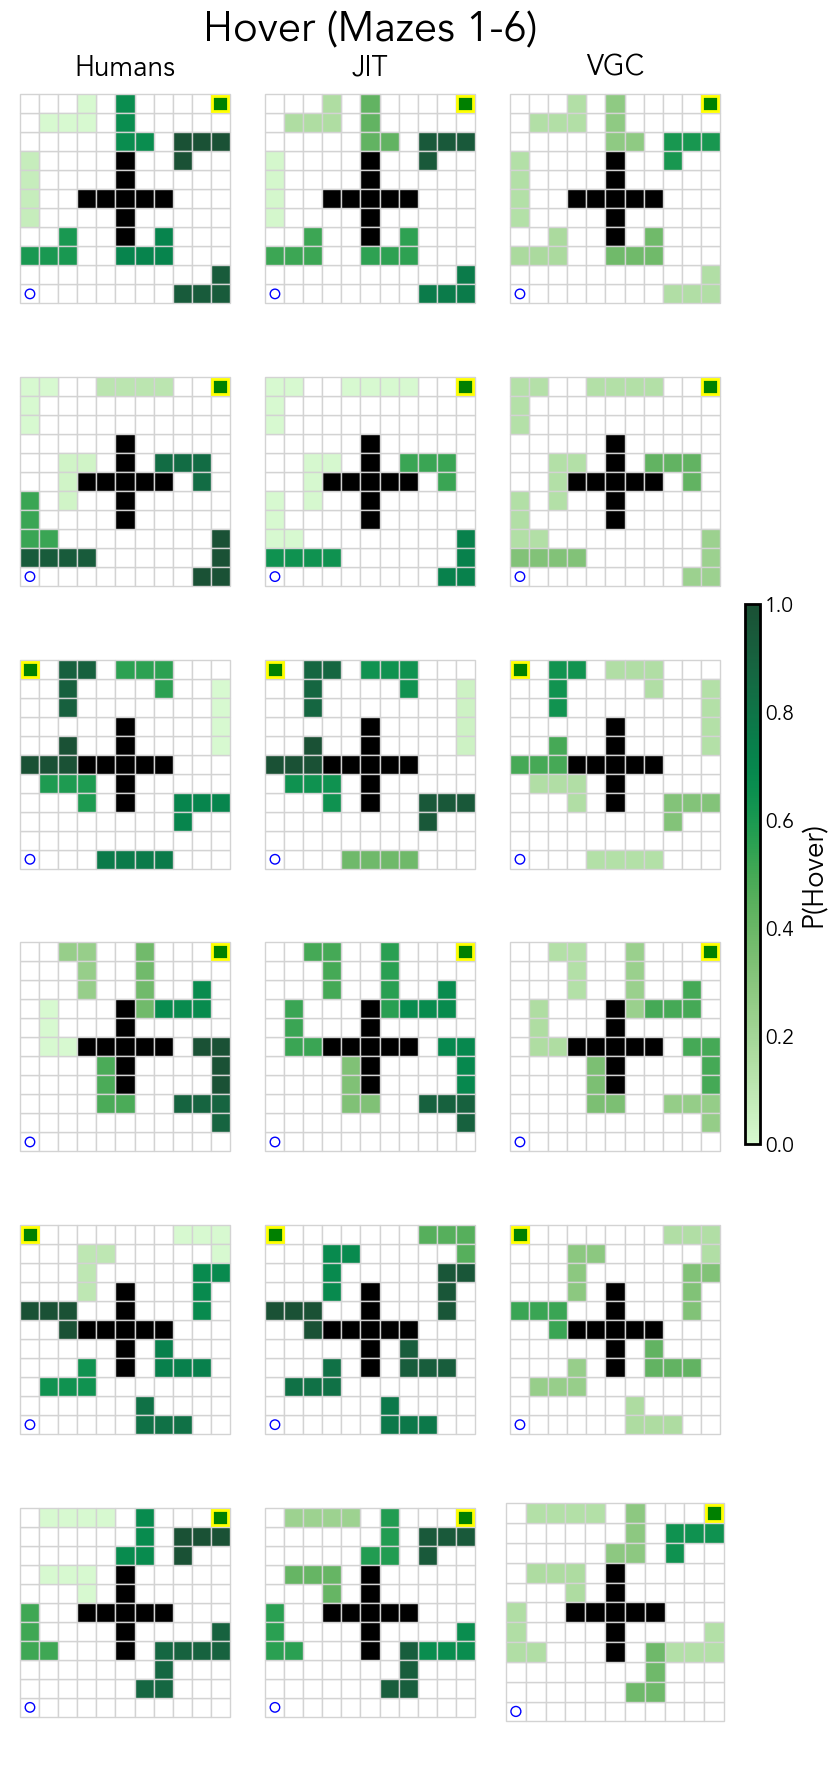

In [17]:
dv = "initial_hover"
# grids = range(12, 16) if "critical" in dv else range(12)
grids = range(6)
rows, cols = len(grids), 3
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 3))
# axes = np.array(axes).T
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=my_cmap, ground_truth=False)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")

fig.tight_layout()
fig.subplots_adjust(top=0.95)
fig.suptitle("Hover (Mazes 1-6)", fontsize=30)
colorbar_ax = fig.add_axes([1.0, 0.35, 0.02, 0.3])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.0, vmax=1.0), cmap=my_cmap), cax=colorbar_ax, orientation='vertical', label='P(Hover)', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
# colorbar_ax.set_xmargin(0.1)
fig.tight_layout()
fig.savefig("../figures/navigation_inithover_heatmap1.pdf", bbox_inches="tight")

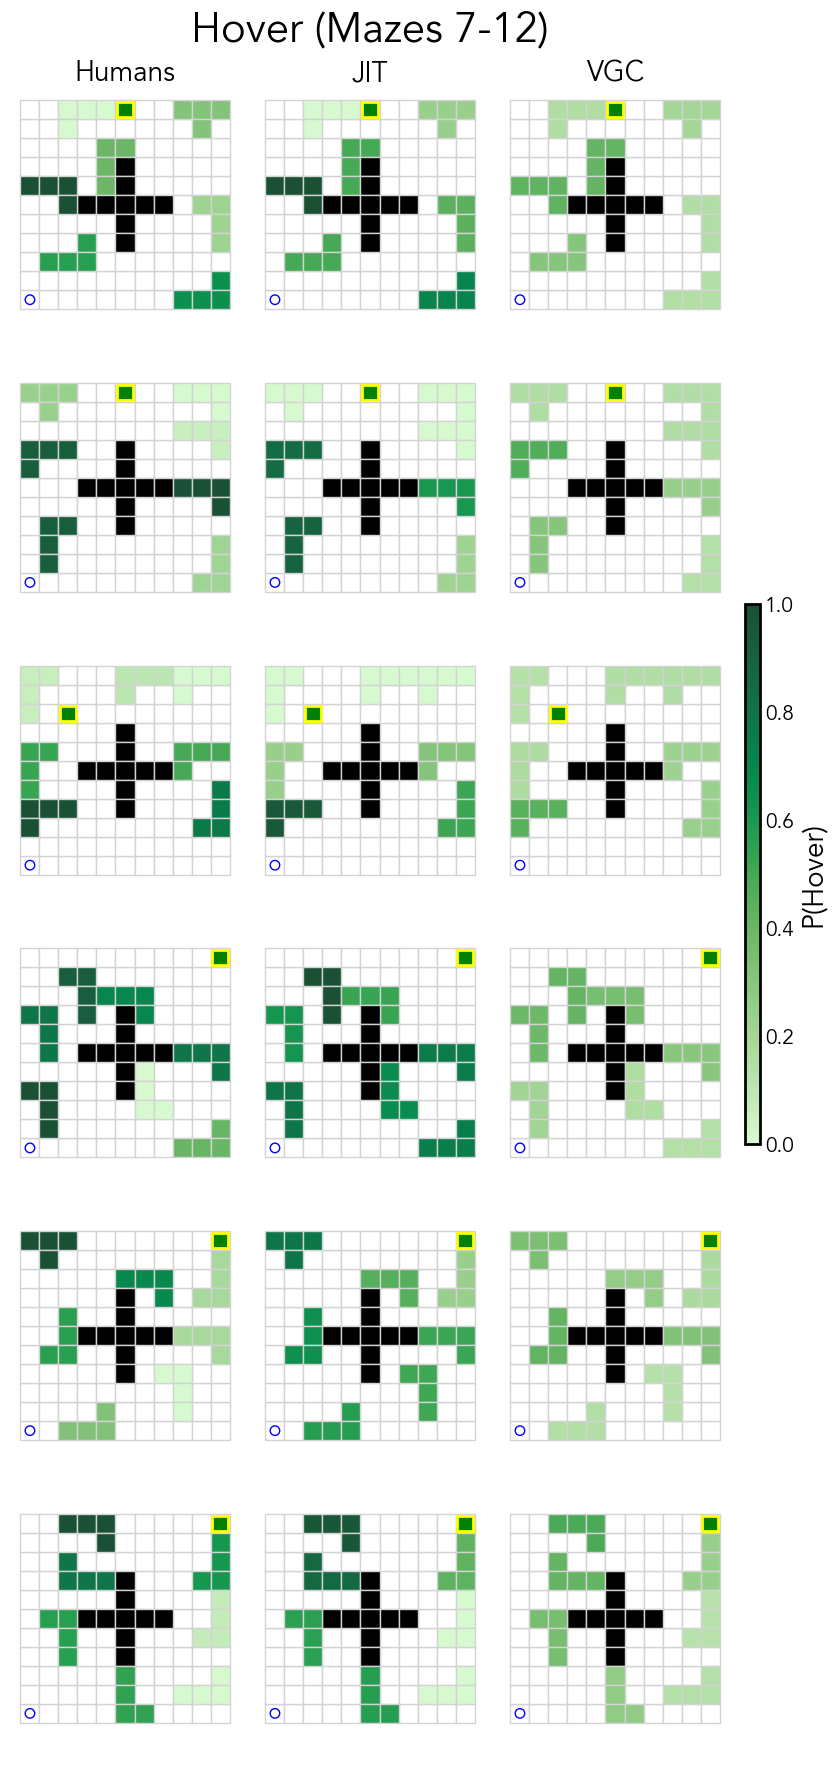

In [18]:
dv = "initial_hover"
# grids = range(12, 16) if "critical" in dv else range(12)
grids = range(6, 12)
rows, cols = len(grids), 3
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 3))
# axes = np.array(axes).T
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=my_cmap, ground_truth=False)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")

fig.tight_layout()
fig.subplots_adjust(top=0.95)
colorbar_ax = fig.add_axes([1.0, 0.35, 0.02, 0.3])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.0, vmax=1.0), cmap=my_cmap), cax=colorbar_ax, orientation='vertical', label='P(Hover)', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
fig.suptitle("Hover (Mazes 7-12)", fontsize=30)
fig.savefig("../figures/navigation_inithover_heatmap2.pdf", bbox_inches="tight")

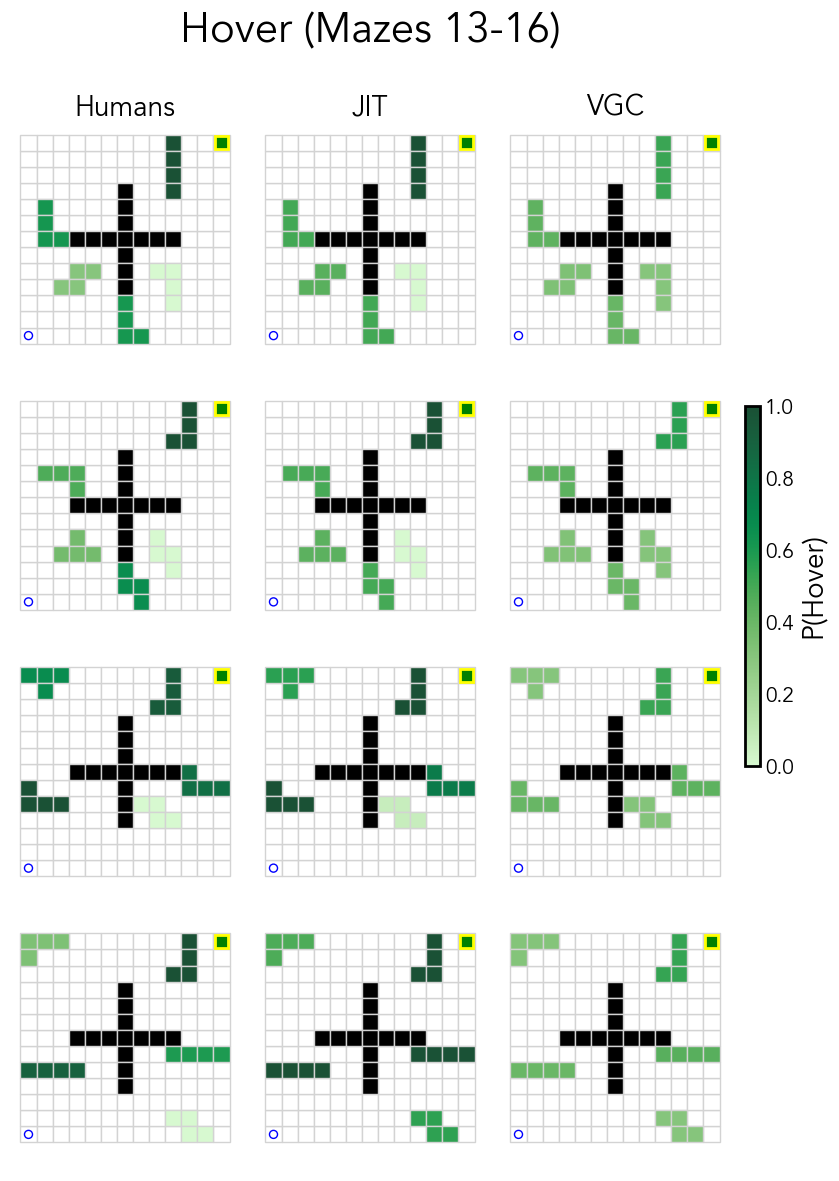

In [19]:
dv = "critical_hover"
grids = range(12, 16) if "critical" in dv else range(12)
rows, cols = len(grids), 3
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 3))
# axes = np.array(axes).T
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=my_cmap, ground_truth=False)
    if i != 0:
        for ax in axes[i]:
            ax.set_title("")

fig.tight_layout()
fig.subplots_adjust(top=0.90)
colorbar_ax = fig.add_axes([1.0, 0.35, 0.02, 0.3])
plt.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=0.0, vmax=1.0), cmap=my_cmap), cax=colorbar_ax, orientation='vertical', label='P(Hover)', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
fig.suptitle("Hover (Mazes 13-16)", fontsize=30)
fig.savefig("../figures/navigation_crithover_heatmap.pdf", bbox_inches="tight")

In [ ]:
def residual_heatmap(
    dv,
    grid,
    jit_predictions,
    vgc,
    norm=True,
    ax=None,
    verbose=False,
    cmap=plt.colormaps["RdBu"],
):
    df, colname = dvs[dv]

    suffix = f" \ngrid {grid}" if verbose else ""
    if ax is None:
        fig, ax = plt.subplots(1, 3, figsize=(12, 3))
    g = mdps.GridWorld.from_string(maze[f"grid-{grid}"])

    tmp_vgc = vgc.loc[(vgc.grid == grid) & (vgc.dv == dv)]
    tmp_jit = jit_predictions.loc[jit_predictions.dv == dv].query(f"grid == {grid}")

    joint_predictions = pd.merge(tmp_vgc, tmp_jit, on=["probeobs", "grid"], how="inner")
    if dv == "critical_memory":
        joint_predictions["dynamic_vgc"] = joint_predictions["dynamic_vgc"] / 2 + 0.5
        joint_predictions["prob"] = joint_predictions["prob"] / 2 + 0.5

    joint_predictions = pd.merge(
        joint_predictions,
        df.groupby(["grid", "probeobs"])[colname].mean().reset_index(),
        on=["probeobs", "grid"],
        how="inner",
    )

    if norm:
        joint_predictions[colname] = (
            joint_predictions[colname] - joint_predictions[colname].min()
        ) / (joint_predictions[colname].max() - joint_predictions[colname].min())

    joint_predictions["vgc_residual"] = (
        joint_predictions["dynamic_vgc"] - joint_predictions[colname]
    )
    joint_predictions["jit_residual"] = joint_predictions["prob"] - joint_predictions[colname]

    rmax = joint_predictions.vgc_residual.abs().max()
    # joint_predictions["vgc_residual"] = (joint_predictions.vgc_residual - rmin) / (rmax - rmin)
    # joint_predictions["jit_residual"] = (joint_predictions.jit_residual - rmin) / (rmax - rmin)
    joint_predictions["vgc_residual"] = joint_predictions.vgc_residual / (2 * rmax) + 0.5 # make sure 0 -> 0.5
    joint_predictions["jit_residual"] = joint_predictions.jit_residual / (2 * rmax) + 0.5 # make sure 0 -> 0.5

    # print(joint_predictions["vgc_residual"].describe())
    # print(joint_predictions["jit_residual"].describe())

    g.viz(start=(0, 0), ax=ax[0], width=2)
    ax[0].set_title(f"Ground Truth{suffix}", fontsize=20)
    ax[0].set_axis_off()
    ax[0].set_aspect("equal")

    colors = [
        cmap((joint_predictions.loc[joint_predictions.probeobs == int(i), "jit_residual"].iloc[0]))
        if i != "#"
        else (0, 0, 0, 1)
        for i in g.obstacle_names
    ]
    g.viz(start=(0, 0), colors=colors, ax=ax[1], width=2)
    # norm = mcolors.Normalize(vmin=0, vmax=1)
    ax[1].set_title(f"ReSiPe-Human{suffix}", fontsize=20)
    ax[1].set_axis_off()
    ax[1].set_aspect("equal")

    colors = [
        cmap((joint_predictions.loc[joint_predictions.probeobs == int(i), "vgc_residual"].iloc[0]))
        if i != "#"
        else (0, 0, 0, 1)
        for i in g.obstacle_names
    ]
    g.viz(start=(0, 0), colors=colors, ax=ax[2], width=2)
    ax[2].set_title(f"VGC-Human{suffix}", fontsize=20)
    ax[2].set_axis_off()
    ax[2].set_aspect("equal")

In [ ]:
dv = "critical_memory"
grids = [13, 14]
fig, axes = plt.subplots(len(grids), 4, figsize=(len(grids) * 4, 4))
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i])

fig.tight_layout()
# fig.subplots_adjust(top=0.90)
# fig.suptitle("Recall", fontsize=30)
fig.savefig("../figures/navigation_heatmaps.pdf", bbox_inches="tight")

In [ ]:
plt.colorbar(cm.ScalarMappable(norm=mpl.colors.Normalize(0.5, 1), cmap=plt.colormaps["Blues"]), label="Memory", ax=plt.gca())
plt.gca().autoscale_view()
# plt.axis("equal")
plt.axis("off")
plt.savefig("../figures/colorbar_title.pdf")

In [ ]:
dv = "critical_hover"
grids = range(12, 16) if "critical" in dv else range(12)
fig, axes = plt.subplots(len(grids), 4, figsize=(len(grids) * 3, 13))

colors = [
    "#4B0082",  # indigo
    "#8000FF",  # violet
    "#FF00FF",  # magenta
    "#FF69B4",  # hot pink
    "#FFD700",  # gold
    "#FFFF00",  # yellow
]
_cmap = mcolors.LinearSegmentedColormap.from_list("dank_purple_yellow", colors)

for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i], cmap=_cmap)

fig.tight_layout()
fig.subplots_adjust(top=0.90)
fig.suptitle("Hover (13-16)", fontsize=30)

In [ ]:
dv = "initial_awareness"
grids = range(12, 16) if "critical" in dv else range(12)
fig, axes = plt.subplots(len(grids), 4, figsize=(13, len(grids) * 3))
for i, grid in enumerate(grids):
    heatmap(dv, grid, jit_predictions, vgc_predictions, mem, norm=True, ax=axes[i])

fig.tight_layout()
fig.subplots_adjust(top=0.95)
fig.suptitle("Awareness", fontsize=30)
# fig.savefig("../figures/navigation_awareness_heatmap.pdf", bbox_inches="tight")

In [ ]:
dv = "initial_awareness"
grids = range(12, 16) if "critical" in dv else range(12)
fig, axes = plt.subplots(len(grids), 3, figsize=(10, len(grids) * 3))
for i, grid in enumerate(grids):
    residual_heatmap(dv, grid, jit_predictions, vgc_predictions, norm=True, ax=axes[i])

fig.tight_layout()
fig.subplots_adjust(top=0.95)
fig.suptitle("Awareness", fontsize=30)
# fig.savefig("../figures/navigation_awareness_heatmap.pdf", bbox_inches="tight")

In [ ]:
dv = "initial_hover"
grids = range(12, 16) if "critical" in dv else range(12)
fig, axes = plt.subplots(len(grids), 3, figsize=(9, len(grids) * 3))
for i, grid in enumerate(grids):
    residual_heatmap(dv, grid, jit_predictions, vgc_predictions, norm=True, ax=axes[i])

fig.tight_layout()
fig.subplots_adjust(top=0.95)
fig.suptitle("Hover (1-11)", fontsize=30)
# fig.savefig("../figures/navigation_hover_residheatmap.pdf", bbox_inches="tight")

In [ ]:
dv = "critical_memory"
grids = range(12, 16) if "critical" in dv else range(12)
fig, axes = plt.subplots(len(grids), 3, figsize=(9, len(grids) * 3))
for i, grid in enumerate(grids):
    residual_heatmap(dv, grid, jit_predictions, vgc_predictions, norm=False, ax=axes[i])

fig.tight_layout()
fig.subplots_adjust(top=0.90)
fig.suptitle("Recall", fontsize=30)
# fig.savefig("../figures/navigation_recall_heatmap.pdf", bbox_inches="tight")

In [ ]:
dv = "critical_hover"
grids = range(12, 16) if "critical" in dv else range(12)
fig, axes = plt.subplots(len(grids), 3, figsize=(9, len(grids) * 3))
for i, grid in enumerate(grids):
    residual_heatmap(dv, grid, jit_predictions, vgc_predictions, norm=True, ax=axes[i])

fig.tight_layout()
fig.subplots_adjust(top=0.90)
fig.suptitle("Hover (12-16)", fontsize=30)
fig.savefig("../figures/navigation_hover_residheatmap.pdf", bbox_inches="tight")

In [ ]:
def figure_heatmap(dv, grid, jit_predictions, vgc, df, norm=True, ax=None):
    df, colname = dv_to_df[dv]
    if ax is None:
        fig, ax = plt.subplots(1, 4, figsize=(12, 3))
    g = mdps.GridWorld.from_string(mazes[f"grid-{grid}"])
    tmp = jit_predictions.loc[jit_predictions.dv == dv].query(f"grid == {grid}")
    colors = [cmap(tmp.loc[tmp.probeobs == int(i), "prob"].iloc[0]) if i != "#" else (0, 0, 0, 1) for i in g.obstacle_names]
    # print(colors)
    g.viz(start=(0, 0), colors=colors, ax=ax[0])
    # norm = mcolors.Normalize(vmin=0, vmax=1)
    ax[0].set_title("ReSiPe", fontsize=10)
    ax[0].set_axis_off()
    ax[0].set_aspect('equal')

    tmp = vgc.loc[(vgc.grid == f"grid-{grid}") & (vgc.dv == dv)]
    colors = [cmap(tmp.loc[tmp.obstacle == f"obs-{i}", "static_vgc"].iloc[0]) if i != "#" else (0, 0, 0, 1) for i in g.obstacle_names]
    g.viz(start=(0, 0), colors=colors, ax=ax[1])
    ax[1].set_title(f"vgc \ngrid {grid}", fontsize=10)
    ax[1].set_axis_off()
    ax[1].set_aspect('equal')

    tmp = vgc.loc[(vgc.grid == f"grid-{grid}") & (vgc.dv == dv)]
    colors = [cmap(tmp.loc[tmp.obstacle == f"obs-{i}", "dynamic_vgc"].iloc[0]) if i != "#" else (0, 0, 0, 1) for i in g.obstacle_names]
    g.viz(start=(0, 0), colors=colors, ax=ax[2])
    ax[2].set_title(f"dynamic vgc \ngrid {grid}", fontsize=10)
    ax[2].set_axis_off()
    ax[2].set_aspect('equal')

    agg = df.groupby(['grid', 'probeobs'])[colname].mean().reset_index()
    tmp = agg.loc[(agg.grid == grid)].reset_index()
    tmp["response"] = tmp[colname]
    if norm:
        rmin = tmp.response.min()
        rmax = tmp.response.max()
    tmp["response"] = (tmp.response - rmin) / (rmax - rmin)  # normalize to between 0 and 1
    # normalize to between 0 and 1
    # tmp["response"] = ( tmp.hovered - rmin) / (rmax - rmin)
    colors = [cmap(tmp.loc[tmp.probeobs == int(i), "response"].iloc[0]) if i != "#" else (0, 0, 0, 1) for i in g.obstacle_names]
    g.viz(start=(0, 0), colors=colors, ax=ax[3])
    ax[3].set_title(f"humans \ngrid {grid}", fontsize=10)
    ax[3].set_axis_off()
    ax[3].set_aspect("equal")
        # fig.subplots_adjust(top=0.9)
        # fig.suptitle(f"{dv}")
dv = "critical_memory"
grids = [12, 13]
fig, axes = plt.subplots(2, 4, figsize=(11, 3 * 2))
for i, grid in enumerate(grids):
    ax = axes[i]
    heatmap(dv, grid, jit_predictions, vgc, mem, norm=True, ax=ax)